# 📚 PyTorch Practice Notebook - Lecture 3: Convolutional Neural Networks

**Based on:** SAIR PyTorch Mastery - Lecture 3: Convolutional Neural Networks - Vision & Beyond

**Instructions:** Complete the exercises below to test your understanding of CNNs and computer vision with PyTorch. Try to solve them without looking at the original notebook first!

**Time Estimate:** 3-4 hours

## 🆕 Enhanced Features:
- Mathematical foundation exercises
- Visualization and interpretation tasks
- Debugging CNN architectures
- Performance analysis
- Sudanese context applications

## 🔧 Setup & Imports

Run this cell first to set up your environment.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

warnings.filterwarnings('ignore')

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU Memory: 15.6 GB


## 🆕 NEW: Debugging Exercise 0 - Find the CNN Bugs!

**Task:** This CNN class has multiple bugs. Identify and fix them all.

In [ ]:
# =========== BUGGY CNN - FIND AND FIX ALL BUGS! ===========
class BuggyCNN(nn.Module):
    """CNN with multiple bugs - fix them all!"""

    def __init__(self, num_classes=10):
        # BUG 1: Missing super().__init__()

        super().__init__()
        # BUG 2: Inconsistent channel sizes
        self.conv1 = nn.Conv2d(3, 32, kernel_size=5, padding=0)  # Will reduce size too much
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5, padding=0)  # Inconsistent padding

        # BUG 3: Wrong calculation of flattened size
        # For 32x32 input with kernel=5, stride=1, padding=0:
        # conv1: 32 -> 28, conv2: 28 -> 24
        # After maxpool (2x): 24 -> 12
        # So flattened size should be 64 * 12 * 12 = 9216
        self.fc1 = nn.Linear(64 * 28 * 28, 256)  # Wrong!

        # BUG 4: Wrong number of classes parameter
        self.fc2 = nn.Linear(256, 100)  # Should be num_classes

        # BUG 5: Missing activation functions
        # Should add ReLU

        # BUG 6: Missing pooling layers

    def forward(self, x):
        # BUG 7: Wrong order of operations
        x = self.conv1(x)
        x = self.conv2(x)  # Should pool between convs

        # BUG 8: Wrong reshape dimensions
        batch_size = x.size(0)
        x = x.view(batch_size, -1)  # This is correct but after wrong flattening calc

        # BUG 9: Missing activation functions
        x = self.fc1(x)
        x = self.fc2(x)

        # BUG 10: No output activation for classification
        return x

# =========== YOUR FIXED VERSION ===========
class FixedCNN(nn.Module):
    """Your fixed version of the buggy CNN"""

    def __init__(self, num_classes=10):
        super().__init__()
        # TODO: Fix all bugs
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=0)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=0)

        # I use kernel size = 3 because it's more reasonable,
        # for 32x32 input :
        # 32x32x3 -> conv1 -> 30x30x32 -> pool -> 15x15x32 -> conv2 -> 13x13x64
        # now adding maxpool
        self.pool = nn.MaxPool2d(2, stride=2)

        # Flattening:
        self.fc1 = nn.Linear(64 * 13 * 13, 256)
        self.fc2 = nn.Linear(256, num_classes)

        self.activation = nn.ReLU()



    def forward(self, x):
        # TODO: Fix forward pass
        x = self.conv1(x)
        x = self.pool(x)
        x = self.conv2(x)

        batch_size = x.size(0)
        x = x.view(batch_size, -1)

        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)

        return x

# Test with a sample input
print("Testing Buggy CNN:")
test_input = torch.randn(4, 3, 32, 32)  # batch_size=4, RGB, 32x32
buggy_model = BuggyCNN()
try:
    output = buggy_model(test_input)
    print(f"Buggy output shape: {output.shape}")
except Exception as e:
    print(f"Buggy model error: {e}")

print("\nTesting Fixed CNN:")
fixed_model = FixedCNN()
# TODO: Test your fixed model
try:
    output_fixed = fixed_model(test_input)
    print(f"Fixed output shape: {output_fixed.shape}")
except Exception as e:
    print(f"You didn't fixed anything idiot!!")

Testing Buggy CNN:
Buggy model error: mat1 and mat2 shapes cannot be multiplied (4x36864 and 50176x256)

Testing Fixed CNN:
Fixed output shape: torch.Size([4, 10])


## 🎯 Exercise 1: Mathematical Foundations & Manual Implementation

### Part A: Manual 2D Convolution

**Task:** Implement 2D convolution from scratch without using PyTorch's `nn.Conv2d`.

In [ ]:
x = np.array([[1,2],[3,4]])
padding = 1
x_padded = np.vstack([np.zeros((padding, x.shape[1])), x, np.zeros((padding, x.shape[1]))])
x_padded = np.hstack([np.zeros((x_padded.shape[0], padding)), x_padded, np.zeros((x_padded.shape[0], padding))])

print(f"Padding: {padding},\n x:\n {x},\n padded:\n {x_padded}")

Padding: 1,
 x:
 [[1 2]
 [3 4]],
 padded:
 [[0. 0. 0. 0.]
 [0. 1. 2. 0.]
 [0. 3. 4. 0.]
 [0. 0. 0. 0.]]


In [ ]:
np.floor(())

array([], dtype=float64)

In [ ]:
x = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9], [10, 11, 12]])
windows = np.lib.stride_tricks.sliding_window_view(x, (2, 2))
windows

array([[[[ 1,  2],
         [ 4,  5]],

        [[ 2,  3],
         [ 5,  6]]],


       [[[ 4,  5],
         [ 7,  8]],

        [[ 5,  6],
         [ 8,  9]]],


       [[[ 7,  8],
         [10, 11]],

        [[ 8,  9],
         [11, 12]]]])

In [ ]:
image = np.arange(12).reshape(3, 4)
kernel = np.arange(12, 16).reshape(2, 2)
stride = 2
print(
    image, kernel,
    sep = "\n",
    )
image_padded = image

# TODO: Get dimensions
# 1. Get dimensions
H, W = image_padded.shape
k_h, k_w = kernel.shape

# TODO: 2. Calculate output dimensions
H_out = np.floor((H - kernel.shape[0]) / stride).astype(int) + 1 # padding already calculated in the update image height
W_out = np.floor((W - kernel.shape[1]) / stride).astype(int) + 1
print(
    f"Output Image Shape: ({H_out},{W_out})",
    sep = "\n",
    )

# 3. Generate Starting Points (Top-Left of each window)
# These are the 'r' and 'c' coordinates
row_starts = np.arange(0, H_out*stride, stride)
col_starts = np.arange(0, W_out*stride, stride)
print(
    f"Row Starts: {row_starts}",
    f"columns Starts: {col_starts}",
    sep = "\n",
)
# Convert 2D start coordinates into Flat Indices: (r * W + c)
# Using broadcasting to get all combinations of row and col starts
start_indices = row_starts[:, None] * W + col_starts
start_indices = start_indices.astype(int).flatten()
print(
    f"start indices: {start_indices}",
    sep = "\n",
)

# 4. Generate Internal Offsets (Relative to the top-left)
# Indices for a k_h x k_w block inside a picture of width W
row_offsets = np.arange(k_h)
col_offsets = np.arange(k_w)

internal_offsets = row_offsets[:, None] * W + col_offsets
internal_offsets = internal_offsets.astype(int).flatten() # shape is (k_h * k_w, )
print(
    f"row offsets: {row_offsets}",
    f"col offsets: {col_offsets}",
    f"internal offsets: {internal_offsets}",
    sep="\n"
)

# 5. The "Magic" Step: Combine Start Points + Internal Offsets
# This creates a (N_patches, k_h*k_w) matrix of every pixel index we need
indices = start_indices[:, None] + internal_offsets[None, :]

print(
    f"indices: {indices}"
)
# 6. Extract Patches and Multiply
image_flat = image_padded.ravel()
patches = image_flat[indices] # grap all indices at once

# Dot product with flattened kernel
result = patches @ kernel.ravel()
# 7. Reshape to the final output grid
result.reshape(H_out, W_out)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[[12 13]
 [14 15]]
Output Image Shape: (1,2)
Row Starts: [0]
columns Starts: [0 2]
start indices: [0 2]
row offsets: [0 1]
col offsets: [0 1]
internal offsets: [0 1 4 5]
indices: [[0 1 4 5]
 [2 3 6 7]]


array([[144, 252]])

In [ ]:
# =========== YOUR CODE HERE ===========
def pad(image, padding=0):
    """
    Perform a 2D padding for an image
    Args:
        image: 2D NumPy Array (H, W)
        padding: Padding Value
    Returns:
        output: Padded image (H+2*padding, W+2*padding)
    """
    # implementing vertical padding:
    v_padder = np.zeros((padding, image.shape[1]))
    padded_image = np.vstack([v_padder, image, v_padder])

    # implementing horizental padding:
    h_padder = np.zeros((padded_image.shape[0], padding))
    padded_image = np.hstack([h_padder, padded_image, h_padder])

    return padded_image

def manual_conv2d(image, kernel, stride=1, padding=0):
    """
    Perform 2D convolution manually.

    Args:
        image: 2D numpy array (H, W)
        kernel: 2D numpy array (kH, kW)
        stride: Stride value
        padding: Padding value

    Returns:
        output: 2D numpy array
    """
    # TODO: Add padding if specified
    # 0. padd the image
    image_padded = pad(image, padding=padding)

    # TODO: Get dimensions
    # 1. Get dimensions
    H, W = image_padded.shape
    k_h, k_w = kernel.shape

    # TODO: 2. Calculate output dimensions
    H_out = np.floor((H - kernel.shape[0]) / stride).astype(int) + 1 # padding already calculated in the update image height
    W_out = np.floor((W - kernel.shape[1]) / stride).astype(int) + 1


    # 3. Generate Starting Points (Top-Left of each window)
    # These are the 'r' and 'c' coordinates
    row_starts = np.arange(0, H_out*stride, stride)
    col_starts = np.arange(0, W_out*stride, stride)

    # Convert 2D start coordinates into Flat Indices: (r * W + c)
    # Using broadcasting to get all combinations of row and col starts
    start_indices = row_starts[:, None] * W + col_starts
    start_indices = start_indices.astype(int).flatten()

    # 4. Generate Internal Offsets (Relative to the top-left)
    # Indices for a k_h x k_w block inside a picture of width W
    row_offsets = np.arange(k_h)
    col_offsets = np.arange(k_w)

    internal_offsets = row_offsets[:, None] * W + col_offsets
    internal_offsets = internal_offsets.astype(int).flatten() # shape is (k_h * k_w, )

    # 5. The "Magic" Step: Combine Start Points + Internal Offsets
    # This creates a (N_patches, k_h*k_w) matrix of every pixel index we need
    indices = start_indices[:, None] + internal_offsets[None, :]

    # 6. Extract Patches and Multiply
    image_flat = image_padded.ravel()
    patches = image_flat[indices] # grap all indices at once

    # Dot product with flattened kernel
    result = patches @ kernel.ravel()
    # 7. Reshape to the final output grid
    return result.reshape(H_out, W_out)



# Test your implementation
print("Testing Manual Convolution:")

# Create test image
test_image = np.array([
    [1, 2, 3, 0, 1],
    [4, 5, 6, 1, 2],
    [7, 8, 9, 2, 3],
    [0, 1, 2, 3, 4],
    [1, 2, 3, 4, 5]
])

# Test with different kernels
identity_kernel = np.array([
    [0, 0, 0],
    [0, 1, 0],
    [0, 0, 0]
])

edge_kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

blur_kernel = np.ones((3, 3)) / 9

# TODO: Test your function with different kernels
# Compare with PyTorch's implementation for verification
# =====================================================

#   I TOLD GEMINI TO GENERATE THIS PILOT TESTING CODE

# =====================================================

def compare_with_pytorch(image, kernel, padding=0, stride=1):
    image_tensor = torch.from_numpy(image).float().unsqueeze(0).unsqueeze(0) # (1, 1, H, W)
    kernel_tensor = torch.from_numpy(kernel).float().unsqueeze(0).unsqueeze(0) # (1, 1, kH, kW)

    conv_layer = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=kernel.shape, stride=stride, padding=padding, bias=False)
    conv_layer.weight = nn.Parameter(kernel_tensor)

    with torch.no_grad():
        output_pytorch = conv_layer(image_tensor).squeeze().numpy()
    return output_pytorch




print("\nComparing with PyTorch's nn.Conv2d:")

# Compare Identity Kernel
# Call manual_conv2d with identity_kernel and print output
output_identity = manual_conv2d(test_image, identity_kernel, padding=1)
print("Output with Identity Kernel:")
print(output_identity)
pytorch_output_identity = compare_with_pytorch(test_image, identity_kernel, padding=1)
print("\nPyTorch Output with Identity Kernel:")
print(pytorch_output_identity)
print(f"Manual and PyTorch outputs are approximately equal: {np.allclose(output_identity, pytorch_output_identity)}")

# Compare Edge Detection Kernel
# Call manual_conv2d with edge_kernel and print output
output_edge = manual_conv2d(test_image, edge_kernel, padding=1)
print("\nOutput with Edge Detection Kernel:")
print(output_edge)
pytorch_output_edge = compare_with_pytorch(test_image, edge_kernel, padding=1)
print("\nPyTorch Output with Edge Detection Kernel:")
print(pytorch_output_edge)
print(f"Manual and PyTorch outputs are approximately equal: {np.allclose(output_edge, pytorch_output_edge)}")

# Compare Blur Kernel
# Call manual_conv2d with blur_kernel and print output
output_blur = manual_conv2d(test_image, blur_kernel, padding=1)
print("\nOutput with Blur Kernel:")
print(output_blur)
pytorch_output_blur = compare_with_pytorch(test_image, blur_kernel, padding=1)
print("\nPyTorch Output with Blur Kernel:")
print(pytorch_output_blur)
print(f"Manual and PyTorch outputs are approximately equal: {np.allclose(output_blur, pytorch_output_blur)}")

Testing Manual Convolution:

Comparing with PyTorch's nn.Conv2d:
Output with Identity Kernel:
[[1. 2. 3. 0. 1.]
 [4. 5. 6. 1. 2.]
 [7. 8. 9. 2. 3.]
 [0. 1. 2. 3. 4.]
 [1. 2. 3. 4. 5.]]

PyTorch Output with Identity Kernel:
[[1. 2. 3. 0. 1.]
 [4. 5. 6. 1. 2.]
 [7. 8. 9. 2. 3.]
 [0. 1. 2. 3. 4.]
 [1. 2. 3. 4. 5.]]
Manual and PyTorch outputs are approximately equal: True

Output with Edge Detection Kernel:
[[ -3.  -3.  10. -13.   5.]
 [  9.   0.  18. -18.   9.]
 [ 38.  30.  44. -14.  12.]
 [-19. -24. -16.  -8.  15.]
 [  5.   9.  12.  15.  29.]]

PyTorch Output with Edge Detection Kernel:
[[ -3.  -3.  10. -13.   5.]
 [  9.   0.  18. -18.   9.]
 [ 38.  30.  44. -14.  12.]
 [-19. -24. -16.  -8.  15.]
 [  5.   9.  12.  15.  29.]]
Manual and PyTorch outputs are approximately equal: True

Output with Blur Kernel:
[[1.33333333 2.33333333 1.88888889 1.44444444 0.44444444]
 [3.         5.         4.         3.         1.        ]
 [2.77777778 4.66666667 4.11111111 3.55555556 1.66666667]
 [2.111111

### Part B: Convolution Mathematics - Shape Calculations

**Task:** Create a function that calculates output dimensions for convolutional layers.

In [ ]:
# =========== YOUR CODE HERE ===========
def calculate_output_size(input_size, kernel_size, stride=1, padding=0, dilation=1):
    """
    Calculate output size for convolution.

    Formula: output = floor((input + 2*padding - dilation*(kernel-1) - 1) / stride) + 1

    Args:
        input_size: Input dimension (H or W)
        kernel_size: Kernel dimension
        stride: Stride value
        padding: Padding value
        dilation: Dilation value

    Returns:
        output_size: Calculated output dimension
    """
    # TODO: Implement the formula
    if not isinstance(input_size, int):
        output_h = np.floor((input_size[0] + 2*padding - dilation*(kernel_size-1) - 1) / stride) + 1
        output_w = np.floor((input_size[1] + 2*padding - dilation*(kernel_size-1) - 1) / stride) + 1
    else:
        output_h = np.floor((input_size + 2*padding - dilation*(kernel_size-1) - 1) / stride) + 1
        output_w = output_h
    return int(output_h), int(output_w)

def calculate_cnn_output_shape(input_shape, conv_layers):
    """
    Calculate final output shape after multiple convolutional layers.

    Args:
        input_shape: Tuple (C, H, W)
        conv_layers: List of dicts with layer parameters
            Example: [{'type': 'conv', 'out_channels': 32, 'kernel': 3, 'stride': 1, 'padding': 1},
                      {'type': 'pool', 'kernel': 2, 'stride': 2}]

    Returns:
        output_shape: Tuple (C, H, W)
    """
    # TODO: Track shape through layers
    current_shape = input_shape[1:]
    current_channels = input_shape[0]
    for conv_info in conv_layers:
        current_shape = calculate_output_size(
            current_shape,
            conv_info['kernel'],
            conv_info.get('stride', 1),
            conv_info.get('padding', 0),
            conv_info.get('dilation', 1)
            )
        if "out_channels" in conv_info.keys():
            current_channels = conv_info['out_channels']
    return (current_channels, current_shape[0], current_shape[1])


# Test cases
print("Test Cases for Shape Calculations:")
print("="*50)

# Test 1: Simple convolution
test1 = calculate_output_size(32, 3, stride=1, padding=1)
print(f"Test 1 - Input 32, kernel 3, stride 1, padding 1: {test1} (expected: 32)")

# Test 2: With pooling
test2 = calculate_output_size(32, 2, stride=2)  # MaxPool2d(2)
print(f"Test 2 - Input 32, kernel 2, stride 2 (pooling): {test2} (expected: 16)")

# Test 3: Complex CNN
layers = [
    {'type': 'conv', 'out_channels': 32, 'kernel': 3, 'stride': 1, 'padding': 1},
    {'type': 'pool', 'kernel': 2, 'stride': 2},
    {'type': 'conv', 'out_channels': 64, 'kernel': 3, 'stride': 1, 'padding': 1},
    {'type': 'pool', 'kernel': 2, 'stride': 2},
]

input_shape = (3, 32, 32)  # CIFAR-10
output_shape = calculate_cnn_output_shape(input_shape, layers)
print(f"\nComplex CNN shape calculation:")
print(f"Input shape: {input_shape}")
print(f"Output shape: {output_shape}")
print(f"Flattened size: {output_shape[0] * output_shape[1] * output_shape[2]}")
# =====================================================

Test Cases for Shape Calculations:
Test 1 - Input 32, kernel 3, stride 1, padding 1: (32, 32) (expected: 32)
Test 2 - Input 32, kernel 2, stride 2 (pooling): (16, 16) (expected: 16)

Complex CNN shape calculation:
Input shape: (3, 32, 32)
Output shape: (64, 8, 8)
Flattened size: 4096


### 🆕 NEW: Part C: Kernel Visualization Challenge

**Task:** Create a visualization tool that shows what different kernels do to images.

Testing Kernel Visualizer:


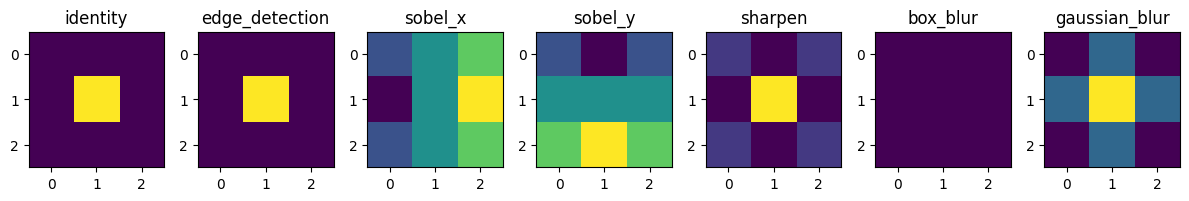

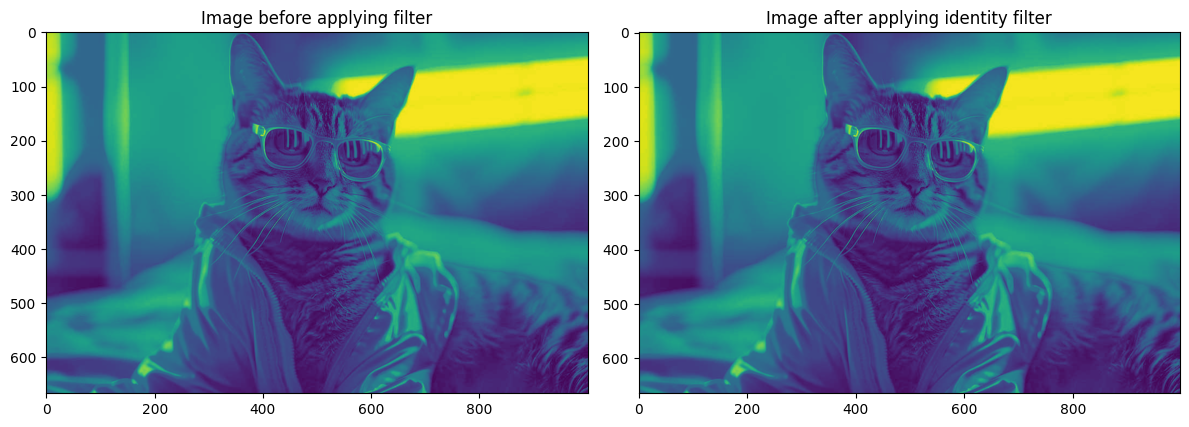

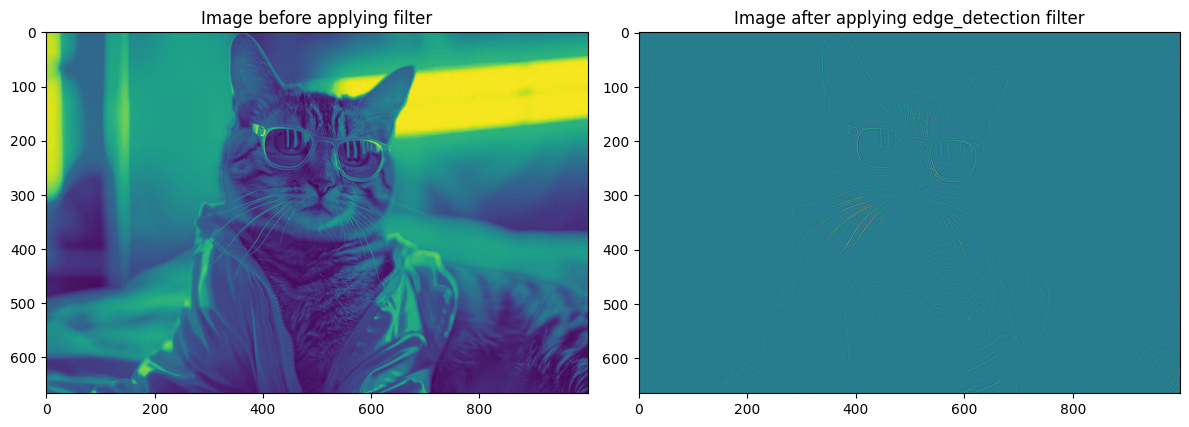

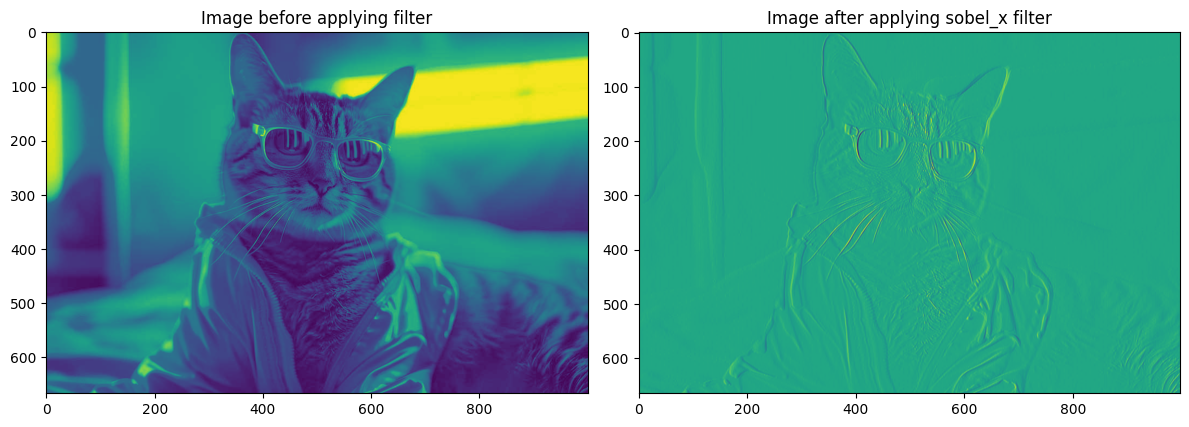

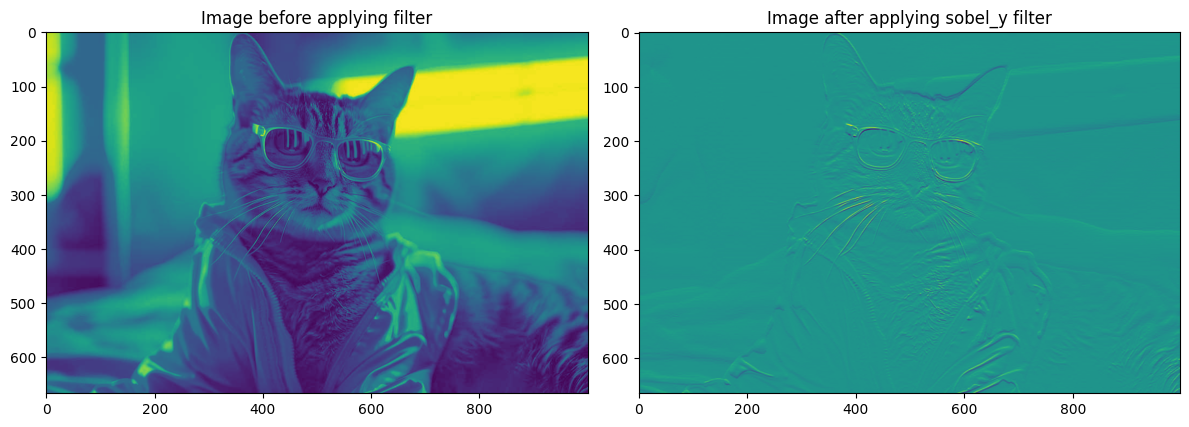

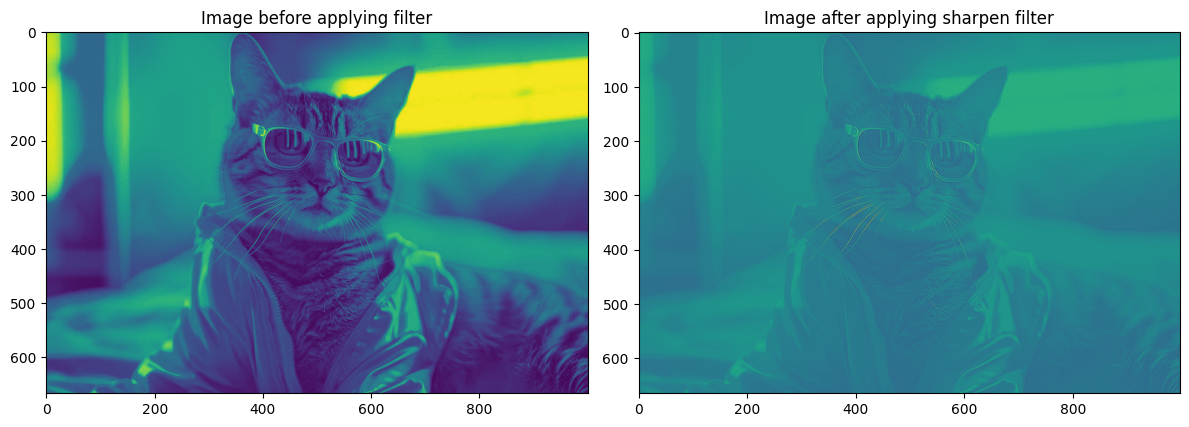

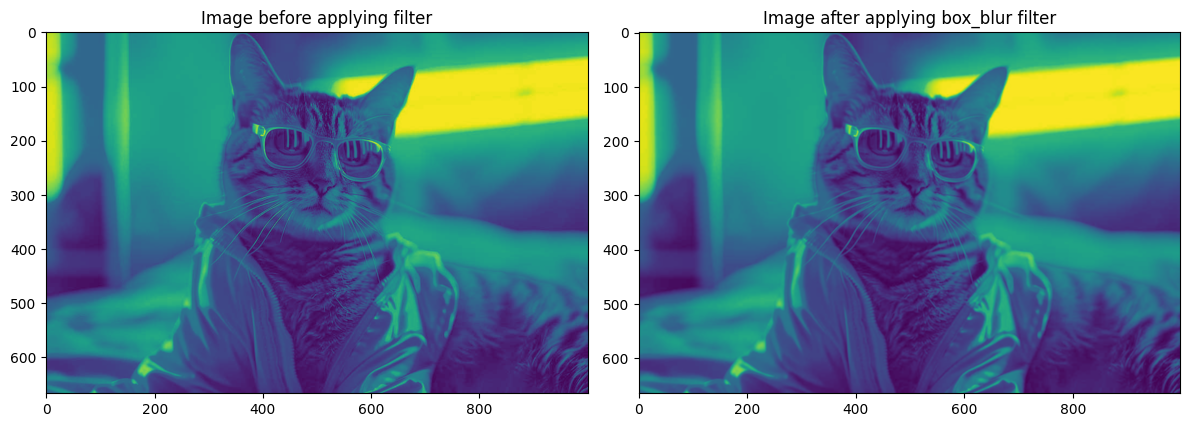

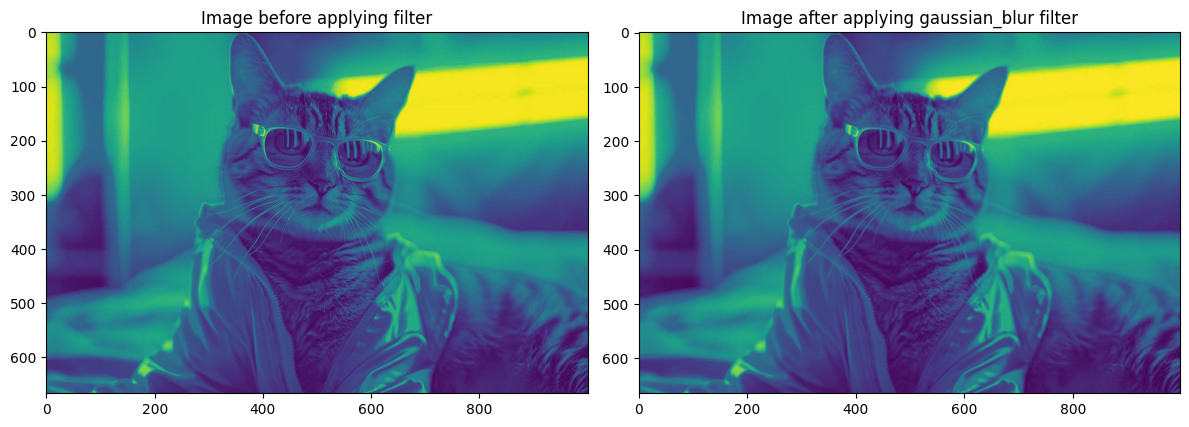

In [ ]:
import requests
from io import BytesIO
def get_image_from_url(url):
    response = requests.get(url)
    # Check if the request was successful
    try:
        # Open the image from the in-memory bytes stream
        img = np.array(Image.open(BytesIO(response.content)).convert("L"))
        # Display or process the image
        #img.show()
    except:
        print(f"Failed to retrieve image. Status code: {response.status_code}, generating random image")
        img = np.random.randn(32, 32)
    return img

class KernelVisualizer:
    """Visualize different convolution kernels"""

    def __init__(self):
        self.kernels = {
            'identity': np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]]),
            'edge_detection': np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]]),
            'sobel_x': np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]),
            'sobel_y': np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]]),
            'sharpen': np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]]),
            'box_blur': np.ones((3, 3)) / 9,
            'gaussian_blur': np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]]) / 16,
        }

    def visualize_kernels(self):
        """Visualize all kernels"""
        # TODO: Create a grid plot of all kernels
        fig, axis = plt.subplots(1, len(self.kernels), figsize = (12, len(self.kernels)*2))

        for i, (key, kernel) in enumerate(self.kernels.items()):
            axis[i].imshow(kernel)
            axis[i].set_title(key)

        plt.tight_layout()
        plt.show()

    def apply_to_image(self, image, kernel_name):
        """Apply kernel to image and show result"""
        # TODO: Apply convolution and show before/after
        transformed_image = manual_conv2d(image, kernel=self.kernels[kernel_name])
        fig, axis = plt.subplots(1, 2, figsize=(12, 8))
        axis[0].imshow(image)
        axis[0].set_title("Image before applying filter")
        axis[1].imshow(transformed_image)
        axis[1].set_title(f"Image after applying {kernel_name} filter")

        plt.tight_layout()
        plt.show()

    def create_custom_kernel(self, weights):
        """Create and test a custom kernel"""
        # TODO: Allow user to create custom kernels
        pass

# Test the visualizer
print("Testing Kernel Visualizer:")
visualizer = KernelVisualizer()
visualizer.visualize_kernels()

image = get_image_from_url("https://www.mamp.one/wp-content/uploads/2024/09/image-resources2.jpg")
for kernel_name in visualizer.kernels.keys():
    visualizer.apply_to_image(image, kernel_name)

## 🏗️ Exercise 2: Building CNN Architectures

### Part A: Build SimpleCNN from Specifications

**Task:** Build a CNN based on these specifications:

**Requirements:**
1. Input: 32x32 RGB images (CIFAR-10)
2. Architecture:
   - Conv1: 32 filters, 3x3, padding=1 → ReLU → BatchNorm → MaxPool(2)
   - Conv2: 64 filters, 3x3, padding=1 → ReLU → BatchNorm → MaxPool(2)
   - Conv3: 128 filters, 3x3, padding=1 → ReLU → BatchNorm → MaxPool(2)
   - Flatten
   - FC1: 256 units → ReLU → Dropout(0.3)
   - FC2: 128 units → ReLU → Dropout(0.3)
   - Output: 10 units (softmax in loss)

3. Total parameters should be less than 500,000

In [ ]:
# =========== YOUR CODE HERE ===========
class SimpleCNN(nn.Module):
    """Your implementation of SimpleCNN"""

    def __init__(self, num_classes=10):
        super().__init__()
        # TODO: Implement the architecture
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)

        self.pool = nn.MaxPool2d(2)
        self.flatten = nn.Flatten()

        self.head = nn.Sequential(
            nn.Linear(32 * 32 * 128, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # TODO: Implement forward pass
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.flatten(x)
        return self.head(x)

    def count_parameters(self):
        """Count total and trainable parameters"""
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total, trainable

# Test your model
print("Testing SimpleCNN:")
model = SimpleCNN()

# Test forward pass
test_input = torch.randn(4, 3, 32, 32)  # batch_size=4
output = model(test_input)
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {output.shape}")

# Count parameters
total_params, trainable_params = model.count_parameters()
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Under 500,000? {total_params < 500000}")

# Print model architecture
print("\nModel Architecture:")
print(model)
# ===========================================

Testing SimpleCNN:
Input shape: torch.Size([4, 3, 32, 32])
Output shape: torch.Size([4, 10])
Total parameters: 33,682,122
Trainable parameters: 33,682,122
Under 500,000? False

Model Architecture:
SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (head): Sequential(
    (0): Linear(in_features=131072, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)


### Part B: Build LeNet (Adapted for CIFAR-10)

**Task:** Implement LeNetNet architecture adapted for 32x32 images.

In [ ]:
def __init__(self, num_classes=10):
    super().__init__()

    # TODO: Implement LeNet-5 architecture for CIFAR-10
    # Original LeNet-5 (for 32x32 images):
    # 1. Conv2d: 1 input channel → 6 output channels, kernel=5x5
    # 2. Tanh activation
    # 3. AvgPool2d: kernel=2x2, stride=2
    # 4. Conv2d: 6 input channels → 16 output channels, kernel=5x5
    # 5. Tanh activation
    # 6. AvgPool2d: kernel=2x2, stride=2
    # 7. Flatten
    # 8. Linear: ? features → 120 units
    # 9. Tanh activation
    # 10. Linear: 120 → 84 units
    # 11. Tanh activation
    # 12. Linear: 84 → num_classes

    # Hints for CIFAR-10 adaptation:
    # - CIFAR-10 has 3 input channels (RGB) not 1 (grayscale)
    # - Input size is 32x32 (same as original LeNet paper)
    # - Need to calculate the flattened size after conv/pool layers

    # TODO: Define the convolutional layers (features extractor)
    self.features = nn.Sequential(
        # Layer 1
        # TODO: First convolutional layer

        # TODO: Activation function (Tanh)

        # TODO: Pooling layer
    )

    # TODO: Calculate the flattened size
    # After first conv (32x32 → ?x?):
    # output_size = (input_size + 2*padding - kernel_size) / stride + 1
    # After first pool: ?x? → ?x?
    # After second conv: ?x? → ?x?
    # After second pool: ?x? → ?x?
    # flattened_size = channels * height * width

    # TODO: Define the fully connected layers (classifier)
    self.classifier = nn.Sequential(
        # TODO: Flatten layer

        # TODO: First fully connected layer

        # TODO: Activation function

        # TODO: Second fully connected layer

        # TODO: Activation function

        # TODO: Output layer
    )

def forward(self, x):
    # TODO: Implement the forward pass
    # Hint: Pass through features, then classifier
    pass

class LeNet(nn.Module):
    def __init__(self, num_classes = 10):
        self.features = nn.Sequential(
            nn.Conv2d(3, 6, 5),
            nn.Tanh(),
            nn.AvgPool2d(2, 2),
            nn.Conv2d(6, 16, 5),
            nn.Tanh(),
            nn.AvgPool2d(2, 2),
            nn.Flatten()
        )

        self.classifier = nn.Sequential(
            nn.Linear(5 * 5 * 16, 120),
            nn.Tanh(),
            nn.Linear(120, 84),
            nn.Tanh(),
            nn.Linear(84, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

## 🔄 Exercise 3: Complete Training & Evaluation


**Task:** Write a complete training loop for cats vs dogs with proper validation and monitoring.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shaunthesheep/microsoft-catsvsdogs-dataset")

print("Path to dataset files:", path)

def prepare_metadata(directory_path = path+'/PetImages'):
    all_files = []

    for root, dirs, files in os.walk(directory_path):
        for file in files:
            # Join the root path with the file name to get the full path
            full_path = os.path.join(root, file)
            all_files.append(full_path)

    metadata = pd.DataFrame({"image_path":all_files})
    metadata['label'] = metadata.image_path.apply(lambda path:str(Path(path).parent)[-3:])
    return metadata


class Cats_vs_Dogs_Dataset(Dataset):
    def __init__(self, metadata, transform = None):
        self.metadata = metadata
        self.label2id = {
            "Cat": 0,
            "Dog": 1
        }
        self.transform = transform
    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        img_path = self.metadata.image_path[idx]
        try:
            # Change dtype to torch.long for CrossEntropyLoss
            label = torch.tensor(self.label2id[self.metadata['label'][idx]], dtype=torch.long)
        except : # Handle cases where label is not 'Cat' or 'Dog'
            label = torch.tensor(0.0) # Return None for problematic labels

        try :
            img = Image.open(img_path).convert("RGB")
        except Exception as e:
            print(f"Yielding random image due to {e}")
            img_array = np.random.randint(
                low=0, high=255, size=(100, 100, 3), dtype=np.uint8
            )
            img = Image.fromarray(img_array)

        if self.transform is not None:
            img = self.transform(img)
        else:
            img = transforms.ToTensor()(img)

        return img, label

    def plot_image(self, idx):
        image = np.array(Image.open(self.metadata.image_path[idx]))
        plt.imshow(image)
        plt.title(self.metadata.label[idx] if 'label' in self.metadata.columns else "")
        plt.legend()
        plt.tight_layout()
        plt.show()

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    #transforms.RandomVerticalFlip(),
    transforms.Resize((256, 256)), # Changed to force square output
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    ),
])

test_transform = transforms.Compose([
    transforms.Resize((256, 256)), # Changed to force square output
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    ),
])


Using Colab cache for faster access to the 'microsoft-catsvsdogs-dataset' dataset.
Path to dataset files: /kaggle/input/microsoft-catsvsdogs-dataset


In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding=0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, padding=padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
        )
    def forward(self, x):
        return self.block(x)

class Cats_vs_Dogs_Model(nn.Module):
    def __init__(self, input_shape=256, num_classes=1): # Changed num_classes to 1
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 64, 3, 1),     # -> input_shape
            nn.MaxPool2d(2, 2),         # -> input_shape / 2
            ConvBlock(64, 128, 3, 1),   # -> input_shape / 2
            nn.MaxPool2d(2, 2)          # -> input_shape / 4
        )
        flatten_size = 128 * (input_shape//4)**2
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flatten_size, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes) # Final layer outputs 1 neuron
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [ ]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    losses = []
    model.train()
    pbar = tqdm(dataloader, desc="Training for one epoch")
    for inputs, label in pbar:
        inputs = inputs.to(device)
        label = label.float().to(device).unsqueeze(1) # Convert label to float and add a dimension for BCEWithLogitsLoss
        output = model(inputs)
        loss = criterion(output, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        pbar.set_postfix(loss=loss.item()) # Update postfix with current loss
    return losses

def test(model, dataloader, device):
    predictions = []
    model.eval()
    with torch.no_grad(): # Disable gradient calculations for evaluation
        pbar = tqdm(dataloader, desc="Evaluating")
        for inputs, _ in pbar:
            inputs = inputs.to(device)
            outputs = model(inputs)
            predictions.append(outputs.cpu().numpy()) # Move predictions to CPU and convert to numpy
    return nn.Sigmoid()(torch.from_numpy(np.concatenate(predictions, axis=0))).numpy()

def metrics_fn(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    y_true = (y_true['label'] == "Dog").astype(int)
    y_pred = (y_pred >= 0.5).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true=y_true, y_pred = y_pred, average='binary')
    acc = accuracy_score(y_pred=y_pred, y_true=y_true)
    return {
        "f1": f1,
        "accuracy": acc,
        "precision": precision,
        "recall": recall
    }

In [ ]:
metadata = prepare_metadata()
metadata = metadata.drop(metadata[metadata.image_path.apply(lambda p: p[-3:]) != 'jpg'].index).reset_index(drop=True)

train_df, val_df = train_test_split(metadata, test_size=0.2, stratify=metadata['label'])
train_df.reset_index(drop=True, inplace=True)
val_df.reset_index(drop=True, inplace=True)
train_ds = Cats_vs_Dogs_Dataset(metadata=train_df, transform=train_transform)
val_ds = Cats_vs_Dogs_Dataset(metadata=val_df, transform=test_transform)

train_dataloader = DataLoader(
    train_ds,
    batch_size = 32,
    num_workers = 2,
    pin_memory=True,
    shuffle = True,
    drop_last=True
)
val_dataloader = DataLoader(
    val_ds,
    batch_size = 32,
    num_workers = 2,
    pin_memory=True,
    shuffle = False,
)

In [ ]:
model = Cats_vs_Dogs_Model(num_classes=1).to(device) # Pass num_classes=1 to the model
optimizer = optim.AdamW(model.parameters(), lr = 1e-3)
criterion = nn.BCEWithLogitsLoss() # Changed to BCEWithLogitsLoss

losses = []
loss_per_epoch = []
scores = []
for epoch in range(3):
    epoch_losses = train_one_epoch(model, train_dataloader, optimizer, criterion, device)
    losses.extend(epoch_losses)
    loss_per_epoch.append(np.mean(epoch_losses))
    preds = test(model, val_dataloader, device)
    score = metrics_fn(val_df, preds)
    scores.append(score)
    for key, val in score.items():
        print(f"{key}: {val}")

Training for one epoch:  19%|█▉        | 121/625 [00:34<01:50,  4.54it/s, loss=11.3]

Yielding random image due to cannot identify image file '/kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Cat/666.jpg'


Training for one epoch:  93%|█████████▎| 582/625 [02:42<00:16,  2.64it/s, loss=0.773]

Yielding random image due to cannot identify image file '/kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Dog/11702.jpg'


Evaluating: 100%|██████████| 157/157 [00:31<00:00,  4.93it/s]


...

Yielding random image due to cannot identify image file '/kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Dog/11702.jpg'


Training for one epoch:  84%|████████▎ | 523/625 [01:49<00:19,  5.26it/s, loss=0.699]

Yielding random image due to cannot identify image file '/kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Cat/666.jpg'


Evaluating: 100%|██████████| 157/157 [00:21<00:00,  7.28it/s]

f1: 0.7442038704732707
accuracy: 0.733
precision: 0.714233173961015
recall: 0.7768


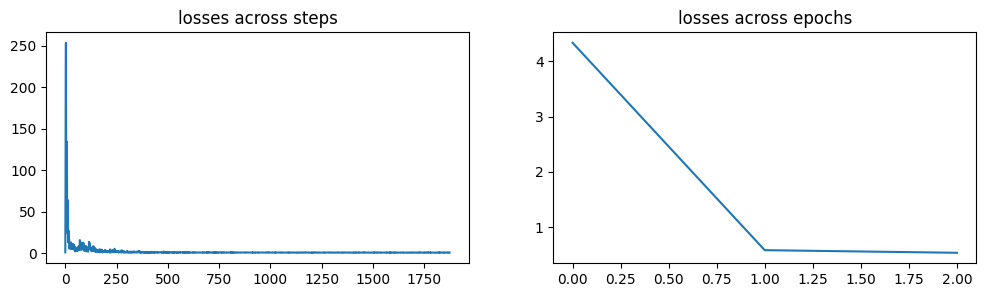

In [ ]:
fig, axis = plt.subplots(1, 2, figsize=(12, 3))

axis[0].plot(losses)
axis[0].set_title("losses across steps")

axis[1].plot(loss_per_epoch)
axis[1].set_title("losses across epochs")
plt.show()

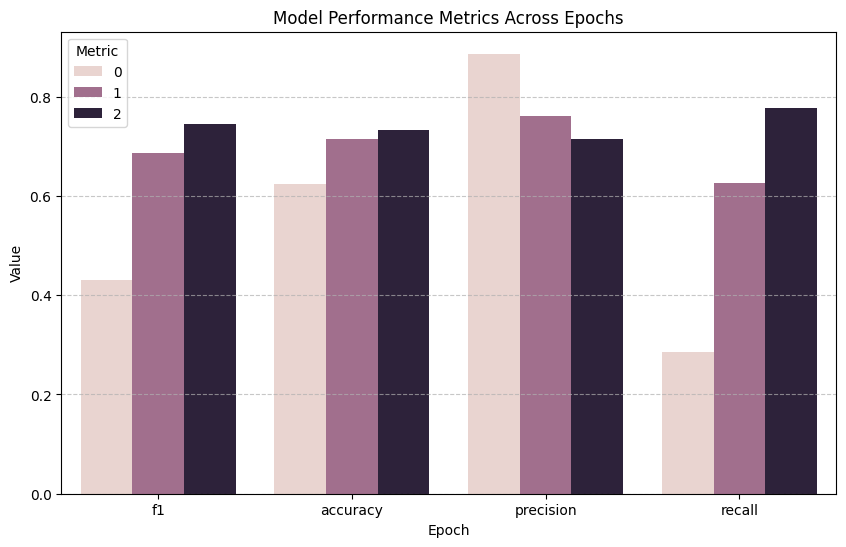

In [ ]:
scores_df = pd.DataFrame(scores)
scores_df['epoch'] = scores_df.index

melted_scores_df = pd.melt(scores_df, id_vars=['epoch'], var_name='metric', value_name='value')


plt.figure(figsize=(10, 6))
sns.barplot(data=melted_scores_df, x='metric', y='value', hue='epoch')
plt.title('Model Performance Metrics Across Epochs')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 🧪 Challenge Problems

### Challenge 1: Optimize CNN for Mobile Deployment

**Task:** Create a lightweight CNN for mobile deployment in Sudanese farms.

In [ ]:
class MobileSudaneseCNN(nn.Module):
    """Lightweight CNN for mobile deployment"""

    def __init__(self, num_classes=5):
        super().__init__()

        # TODO: Design a CNN with:
        # 1. Less than 100,000 parameters
        # 2. Fast inference on mobile CPU
        # 3. Good accuracy for crop classification

        # Techniques to consider:
        # - Depthwise separable convolutions
        # - Bottleneck layers
        # - Reduced channel counts
        # - Efficient activation functions

    def forward(self, x):
        pass

    def benchmark(self, input_size=(1, 3, 224, 224)):
        """Benchmark model performance"""
        # TODO: Measure parameters, FLOPs, inference time
        pass

print("Testing Mobile CNN:")
mobile_cnn = MobileSudaneseCNN()
mobile_cnn.benchmark()

Testing Mobile CNN:


In [ ]:
!pip install thop

In [ ]:
import time
import torch
from thop import profile

class DepthwiseSeperableConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super().__init__()
        self.depth_wise = nn.Conv2d(
            in_channels=in_channels, out_channels=in_channels, kernel_size=kernel_size, padding=padding, groups=in_channels
        ) # Groups ensures that each channels get its own kernel
        self.point_wise = nn.Conv2d(
            in_channels=in_channels, out_channels=out_channels, kernel_size=1
        )

    def forward(self, x):
        x = self.depth_wise(x)
        x = self.point_wise(x)
        return x

class MobileSudaneseCNN(nn.Module):
    """Lightweight CNN for mobile deployment"""

    def __init__(self, input_size=224, num_classes=5):
        super().__init__()

        # TODO: Design a CNN with:
        # 1. Less than 100,000 parameters
        # 2. Fast inference on mobile CPU
        # 3. Good accuracy for crop classification

        # Techniques to consider:
        # - Depthwise separable convolutions
        # - Bottleneck layers
        # - Reduced channel counts
        # - Efficient activation functions
        self.features = nn.Sequential(
            DepthwiseSeperableConvBlock(3, 8),   # 224x224x3 -> 224x224x8
            DepthwiseSeperableConvBlock(8, 16), # 224x224x8 -> 224x224x16
            nn.ReLU(),
            nn.MaxPool2d(2, 2),         # 224x224x16 -> 112x112x16
            DepthwiseSeperableConvBlock(16, 32), # 112x112x16 -> 112x112x32
            DepthwiseSeperableConvBlock(32, 64), # 112x112x32 -> 112x112x64
            nn.ReLU(),
            nn.MaxPool2d(2, 2),         # 112x112x64 -> 56x56x64
        )
        # Using nn.AdaptiveAvgPool2d((1,1)) to replace nn.Flatten() for Global Average Pooling
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)), # Output will be (batch_size, 64, 1, 1)
            nn.Flatten(), # Flatten to (batch_size, 64)
            nn.Linear(64, 256), # in_features is now 64
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

    def benchmark(self, input_size=(1, 3, 224, 224)):
        """Benchmark model performance"""
        # Count parameters
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Total parameters: {total_params:,}")
        print(f"Trainable parameters: {trainable_params:,}")

        # Calculate FLOPs
        dummy_input = torch.randn(input_size)
        macs, params = profile(self, inputs=(dummy_input, ), verbose=False)
        # FLOPs are typically 2 * MACs for convolution, but thop often reports MACs directly.
        # Let's just report MACs for simplicity or explicitly state FLOPs = 2 * MACs.
        # For most practical purposes, MACs ~ FLOPs (or FLOPs = 2*MACs depending on definition)
        print(f"Estimated GFLOPs: {macs / 1e9:.2f}")

        # Measure inference time
        self.eval()
        with torch.no_grad():
            # Warm-up runs
            for _ in range(10):
                self(dummy_input)

            start_time = time.time()
            num_runs = 100
            for _ in range(num_runs):
                self(dummy_input)
            end_time = time.time()
            avg_inference_time = (end_time - start_time) / num_runs * 1000 # milliseconds
        print(f"Average inference time: {avg_inference_time:.2f} ms")

print("Testing Mobile CNN:")
mobile_cnn = MobileSudaneseCNN()
mobile_cnn.benchmark()

Testing Mobile CNN:
Total parameters: 21,347
Trainable parameters: 21,347
Estimated GFLOPs: 0.05
Average inference time: 15.27 ms


### Challenge 2: Multi-Task CNN

**Task:** Create a CNN that performs multiple tasks for Sudanese agriculture.

In [ ]:
class MultiTaskAgricultureCNN(nn.Module):
    """CNN for multiple agricultural tasks"""

    def __init__(self):
        super().__init__()

        # Shared backbone
        self.backbone = nn.Sequential(
            # TODO: Shared convolutional layers
        )

        # Task-specific heads
        self.crop_classifier = nn.Sequential(
            # TODO: Classify crop type (5 classes)
        )

        self.health_classifier = nn.Sequential(
            # TODO: Classify health status (3 classes)
        )

        self.yield_regressor = nn.Sequential(
            # TODO: Predict yield (continuous value)
        )

    def forward(self, x):
        features = self.backbone(x)

        crop_pred = self.crop_classifier(features)
        health_pred = self.health_classifier(features)
        yield_pred = self.yield_regressor(features)

        return {
            'crop_type': crop_pred,
            'health_status': health_pred,
            'yield': yield_pred
        }

    def multi_task_loss(self, predictions, targets):
        """Compute combined loss for all tasks"""
        # TODO: Weighted combination of:
        # 1. Cross-entropy for crop classification
        # 2. Cross-entropy for health classification
        # 3. MSE for yield regression
        pass

print("Testing Multi-Task CNN:")
# TODO: Implement and test

Testing Multi-Task CNN:


In [ ]:
class MultiTaskAgricultureCNN(nn.Module):
    """CNN for multiple agricultural tasks"""

    def __init__(self, input_size):
        super().__init__()

        # Shared backbone
        self.backbone = nn.Sequential(
            ConvBlock(3, 64, 3, 1),
            nn.MaxPool2d(2, 2),
            ConvBlock(64, 128, 3, 1),
            nn.MaxPool2d(2, 2),
            ConvBlock(128, 256, 3, 1),
            nn.MaxPool2d(2, 2),
            nn.Flatten()
        )

        # Task-specific heads
        self.crop_classifier = nn.Sequential(
            # TODO: Classify crop type (5 classes)
            nn.Linear(256 * (input_size // 4)**2, 256),
            nn.ReLU(),
            nn.Linear(256, 5),
        )

        self.health_classifier = nn.Sequential(
            # TODO: Classify health status (3 classes)
            nn.Linear(256 * (input_size // 4)**2, 256),
            nn.ReLU(),
            nn.Linear(256, 3),
        )

        self.yield_regressor = nn.Sequential(
            # TODO: Predict yield (continuous value)
            nn.Linear(256 * (input_size // 4)**2, 256),
            nn.ReLU(),
            nn.Linear(256, 1),
        )

        self.clf_loss_fn = nn.BCEWithLogitsLoss()
        self.rg_loss_fn = nn.MSELoss()
    def forward(self, x):
        features = self.backbone(x)

        crop_pred = self.crop_classifier(features)
        health_pred = self.health_classifier(features)
        yield_pred = self.yield_regressor(features)

        return {
            'crop_type': crop_pred,
            'health_status': health_pred,
            'yield': yield_pred
        }

    def multi_task_loss(self, predictions, targets):
        """Compute combined loss for all tasks"""
        # TODO: Weighted combination of:
        # 1. Cross-entropy for crop classification
        crop_loss = self.clf_loss_fn(predictions['crop_type'], targets['crop_type'])
        # 2. Cross-entropy for health classification
        health_loss = self.clf_loss_fn(predictions['health_status'], targets['health_status'])
        # 3. MSE for yield regression
        yield_loss = self.rg_loss_fn(predictions['yield'], targets['yields'])

        return np.mean([crop_loss, health_loss, yield_loss])

print("Testing Multi-Task CNN:")
# TODO: Implement and test

Testing Multi-Task CNN:


## 📊 Assessment Questions

Answer these questions in markdown cells:

### Q1: What's the key difference between a dense layer and a convolutional layer? When would you use each?

- Danse layer consist of fully connected neurons, convolutional layer consist of neurons (filters or weights) connected on a limited manner, use mainly for images by sliding the neurons on the image, unlike Dense layer, it serve the position and color informations.
- We use Dense Layer for simple feature extraction (like tabular date, or data comes from a feature extractor's like cnn), and we use convolution layer with images mainly, with applicability to some temporal and positional data.

---

### Q2: How does padding affect convolution output size and feature learning?
- Padding adjust the origianl image shape by adding a dummy pixels, it increase the image dimensions, generally, the padding set to 0 so one's it multiplied with the weights it must have no effect, but it effects the sum of the weight's.
- Padding helps serving the dimensions of the original image.
---

### Q3: Why do CNNs use small kernel sizes (3x3) instead of large ones?
- to reduce parameters while enhancing non-linearity (using two layers of 3x3 filters with two activation functions is better than using one 5x5 layer, and lesser parameters).
- using a lot of 3x3 filter is equivelant to using lesser larger filters.
- increase model depth.
---

### Q4: What's the purpose of pooling layers in CNNs? What are the trade-offs between max pooling and average pooling?
- reduce the image dimensions, which minimize training time by reducing the number of weights.
- max pooling: helps detecting sharp features like edges and brightness, less effected by noise, preferred in the biggining layers, it literally says that 'I highlight the excistense of a feature whithout paying attention that where it is actually', the main consequences is that it discard non-maximum features.
- average pooling: help smoothing and serving the features, affected by noise, preferred in the deeper and last layers because it summarizes and smoothes the extracted features.

---

### Q5: How does BatchNorm help with CNN training? Why does it behave differently during training vs inference?
- in general, batch normalization helps reducing training time by helping the network to adjust the weights in a smooth and simple manner.
- in training time, normalization works on *Batch*, but in inference time, there may be no batching or different batch size, so the BatchNorm layer use its learnable weights to adjust the inference values.
---
### Q6: Explain the concept of "receptive field" in CNNs. How does it change through the network?
---
### Q7: What's the difference between Conv1D, Conv2D, and Conv3D? Give real-world examples for each.
- the difference is in the `dimenstion` of the convolution:
1. Conv1D: used for precessing sequence data, such as timeseries, audio or text data.
2. Conv2D: used for processing image data (2d spatial data).
3. Conv3D: used for precessing 3d images (volumetric data, medical imaging and video data).
### 🆕 Q8: Design a CNN architecture for classifying Sudanese traditional clothing. What considerations would you make?

### 🆕 Q9: How would you optimize a CNN for deployment on mobile phones in rural Sudan?

### 🆕 Q10: Create a debugging checklist for when your CNN isn't learning (low accuracy).




**You're ready for Lecture 4: Transfer Learning & Advanced Architectures!** 🎉

## 💡 Tips for Success

1. **Start Simple**: Begin with manual convolution, then use PyTorch layers
2. **Visualize Everything**: Use the visualization tools to understand what's happening
3. **Test Shapes**: Always print tensor shapes between layers
4. **Consider Sudanese Context**: Think about real applications in Sudan
5. **Benchmark**: Compare different architectures and techniques
6. **🆕 Debug Systematically**: When something doesn't work, check shapes, devices, gradients
7. **🆕 Think About Deployment**: Consider computational constraints

## 🤝 Need Help?

- Review Lecture 3 notebook for concepts
- Use PyTorch documentation for specific APIs
- Test with small examples first
- Visualize intermediate results
- 🆕 Create minimal reproducible examples when debugging
- 🆕 Benchmark different approaches to find optimal solutions

### Very Important Note:
# Go to Chapter 11 of Hands On Machine Learning with sklearn and PyTorch by Aurélien Géron.and solve the exercises at the end of the chapter.and add it in this notebook as well.